In [ ]:
!pip install mediapipe opencv-python tensorflow keras


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 25.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.4
    Uninstalling protobuf-5.29.4:
      Successfully uninstalled protobuf-5.29.4
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.0 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.7 which is incompatible.
ydf 0.11.0 requires protobuf<6.0.0,>=5.29.1, but you have protobuf 4.25.7 which is inc

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
zip_path = '/content/drive/MyDrive/Colab Notebooks/facemask/archive (2).zip'

In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/Colab Notebooks/facemask/archive (2).zip'
extract_path = '/content/facemask_dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Unzipped successfully to:", extract_path)


✅ Unzipped successfully to: /content/facemask_dataset


In [ ]:
import os

os.listdir('/content/facemask_dataset')


['data']

In [ ]:
import os
import shutil
import random

# Set seed for reproducibility
random.seed(42)

# Paths
original_data_dir = '/content/facemask_dataset/data'


base_dir = '/content/drive/MyDrive/Colab Notebooks/facemask/split_data'

# Create target directories
splits = ['train', 'val', 'test']
classes = ['with_mask', 'without_mask']

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Function to split and copy files
def split_and_copy(class_name):
    source_dir = os.path.join(original_data_dir, class_name)
    all_files = os.listdir(source_dir)
    random.shuffle(all_files)

    total = len(all_files)
    train_count = int(total * train_ratio)
    val_count = int(total * val_ratio)

    train_files = all_files[:train_count]
    val_files = all_files[train_count:train_count + val_count]
    test_files = all_files[train_count + val_count:]

    for fname in train_files:
        shutil.copy(os.path.join(source_dir, fname), os.path.join(base_dir, 'train', class_name, fname))

    for fname in val_files:
        shutil.copy(os.path.join(source_dir, fname), os.path.join(base_dir, 'val', class_name, fname))

    for fname in test_files:
        shutil.copy(os.path.join(source_dir, fname), os.path.join(base_dir, 'test', class_name, fname))

# Apply to each class
for cls in classes:
    split_and_copy(cls)

print("✅ Data successfully split into train, val, and test folders!")


✅ Data successfully split into train, val, and test folders!


In [ ]:
# Paths
base_dir = '/content/drive/MyDrive/Colab Notebooks/facemask/split_data'

#Image processing
img_height, img_width= 150,150
batch_size=32

train_datagen = ImageDataGenerator(rescale=1./255)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator =train_datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, 'val'),
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, 'test'),
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 5286 images belonging to 2 classes.
Found 1132 images belonging to 2 classes.
Found 1135 images belonging to 2 classes.


In [ ]:
#model definition
model= Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(img_height,  img_width, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer= 'adam', loss='binary_crossentropy', metrics=['accuracy'])

# Training
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
 14/166 ━━━━━━━━━━━━━━━━━━━━ 46s 307ms/step - accuracy: 0.5957 - loss: 0.6456

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


166/166 ━━━━━━━━━━━━━━━━━━━━ 40s 206ms/step - accuracy: 0.8127 - loss: 0.4006 - val_accuracy: 0.9187 - val_loss: 0.2045
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 29s 175ms/step - accuracy: 0.9102 - loss: 0.2354 - val_accuracy: 0.9205 - val_loss: 0.1928
Epoch 3/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 30s 178ms/step - accuracy: 0.9251 - loss: 0.1959 - val_accuracy: 0.9346 - val_loss: 0.1677
Epoch 4/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 29s 177ms/step - accuracy: 0.9418 - loss: 0.1528 - val_accuracy: 0.9417 - val_loss: 0.1409
Epoch 5/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 29s 172ms/step - accuracy: 0.9528 - loss: 0.1269 - val_accuracy: 0.9567 - val_loss: 0.1224
Epoch 6/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 29s 174ms/step - accuracy: 0.9664 - loss: 0.0930 - val_accuracy: 0.9620 - val_loss: 0.1060
Epoch 7/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 29s 174ms/step - accuracy: 0.9717 - loss: 0.0787 - val_accuracy: 0.9620 - val_loss: 0.1207
Epoch 8/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 29s 173ms/step - accuracy: 0.9770 - loss: 0.0613 - val

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")


36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 150ms/step - accuracy: 0.9486 - loss: 0.2129
Test accuracy: 95.33%
Test loss: 0.1818


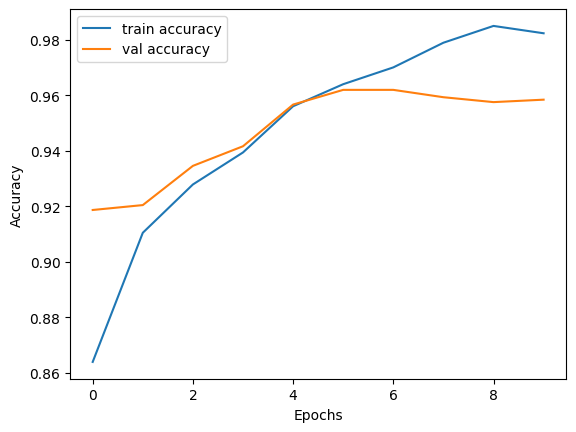

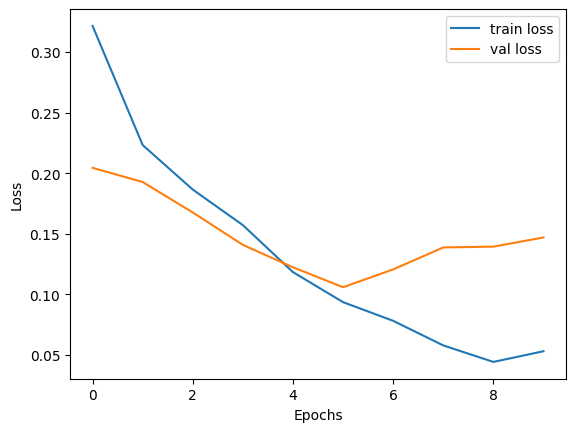

In [ ]:
#Plot Training & Validation Accuracy/Loss: Visualize how well the model trained and if it's overfitting.
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training & validation loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
model.save('/content/drive/MyDrive/Colab Notebooks/facemask/facemask_model.h5')
print("✅ Model saved successfully!")


✅ Model saved successfully!


In [ ]:
# Path to the image you want to test
image_path = '/content/facemask_dataset/data/without_mask/without_mask_1000.jpg'
## Load the image, resize it to match the input shape of the model
img= image.load_img(image_path, target_size=(150,150))

#Convert the image to a numpy array
img_array= image.img_to_array(img)

#Expand the dimensions to match the input shape (batch_size, height, width, channels)
img_array=np.expand_dims(img_array, axis=0)

#Rescale the image (same as you did for training)
img_array/=255.0


In [ ]:
#make the prediction
prediction= model.predict(img_array)

# Since it's binary classification, use a threshold of 0.5
if prediction >= 0.5:
    print("The person is not wearing a mask!")
else:
    print("The person is wearing a mask!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
The person is not wearing a mask!


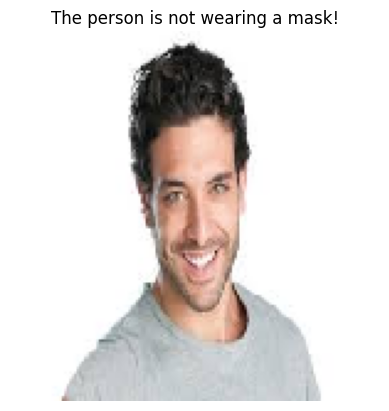

In [ ]:
import matplotlib.pyplot as plt

# Display the image
plt.imshow(img)
plt.axis('off')  # Hide axes
if prediction >= 0.5:
    plt.title("The person is not wearing a mask!")
else:
    plt.title("The person is wearing a mask!")
plt.show()
